In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
print(torch.cuda.get_device_name(0))

Tesla T4


In [ ]:
import sys

!{sys.executable} -m pip install transformers torch scikit-learn pandas

In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


In [ ]:
import os
print(os.path.exists(r"C:\Users\niraj\.cache\huggingface\hub\models--bert-base-uncased"))

False


In [ ]:
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("IMDB_Dataset.csv",
                engine="python",
                on_bad_lines="skip"
)

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    19015
negative    18994
Name: count, dtype: int64


In [ ]:
df.shape

(38009, 2)

In [ ]:
df['sentiment'] = df['sentiment'].map({
    'negative':0,
    'positive':1
})
print(df.head())
print(df['sentiment'].value_counts())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1
sentiment
1    19015
0    18994
Name: count, dtype: int64


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
train_text, temp_text, train_labels, temp_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.20,
    random_state=2021,
    stratify=df['sentiment']
)

val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text,
    temp_labels,                                  # val_text -> validation reviews
    test_size = 0.50,                              # val_label -> validation ke sentiment labels
    random_state=2021,
    stratify = temp_labels
)

print("training: ", len(train_text))
print("Validation: ", len(val_text))
print("Test sample: ", len(test_text))
print("Total:", len(train_text) + len(val_text) + len(test_text))

training:  30407
Validation:  3801
Test sample:  3801
Total: 38009


# Load BERT Tokenizer & Model
load the pre-trained bert-based-uncased tokenizer and model. The tokenizer converts the review text into token IDs that BERT can process.

In [ ]:
# "This movie is amazing" -> Tokenizer -> ["this", "movie", "is", "amazing"] -> Token IDs -> [2023, 3185, 2003, 6429]
from transformers import BertTokenizerFast, BertForSequenceClassification

tokenizer = BertTokenizerFast.from_pretrained(
    'bert-base-uncased'
)

# Review -> BERT -> [score for 0, score for 1]  ->  [negative score, positive score]
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Tokenizing the Data
BERT can process a fixed maximum number of tokens for each input. We use a maximum sequence length of 64 tokens to keep training faster. Longer reviews are truncated, while shorter reviews are padded when batches are created.

In [ ]:
max_length = 64

In [ ]:
class SentimentDataset(Dataset):   # Reviews + Labels -> IMDBDataset -> Tokenizer -> BERT-compatible data
    def __init__(self, texts, labels, tokenizer, max_length=120):
        self.texts = texts.tolist()      # Pandas Series -> ["This movie is great", "Very bad movie", ...]
        self.labels = labels.tolist()     #  [1, 0, 1, 0, ...]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        encoding = self.tokenizer(
            self.texts[index],
            truncation=True,
            padding = "max_length",
            max_length=self.max_length,
            return_tensors="pt"    # output of Tokenizer directly convert into PyTorch tensor
        )

        encoding = {key: value.squeeze(0) for key, value in encoding.items()}

        encoding['labels']= torch.tensor(
            self.labels[index],
            dtype=torch.long
        )
        return encoding

# Create datasets for training, validation and texting

In [ ]:
train_dataset = SentimentDataset(
    train_text, train_labels, tokenizer, max_length = 128
)

val_dataset = SentimentDataset(
    val_text, val_labels, tokenizer, max_length = 128
)

test_dataset = SentimentDataset(
    test_text, test_labels, tokenizer, max_length = 128
)

In [ ]:
print(len(train_dataset))
print(train_dataset[0])

30407
{'input_ids': tensor([  101,  1045,  2387,  1996,  2143,  2012,  1996,  6613,  2248,  2143,
         2782,  1006,  2088,  6765,  1007,  1012,  1026,  7987,  1013,  1028,
         1026,  7987,  1013,  1028,  1037, 20161,  1010, 10305,  6533,  1997,
        20334,  1010,  1998,  1996, 16360,  2121,  7874, 27466,  1997,  5599,
         2009,  4982,  1998,  2735,  2046,  2242,  9904,  1012,  1026,  7987,
         1013,  1028,  1026,  7987,  1013,  1028,  1996,  3772,  1997,  1996,
         2048,  5260,  1006,  8201,  8945,  7317,  1004,  2957,  7987, 18426,
         3351,  1007,  2003,  6581,  1010,  1998,  3084,  2028,  4299,  2017,
         2018,  2777,  2122,  3494,  2077,  2027,  2150,  2061,  5591,  1012,
         1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  6966,  2033,
         1999,  4323,  1997,  1996,  2573,  1997, 13787, 13059,  7054,  1006,
        12564,  2050,  1007,  1998,  7638, 20163,  1006,  2073,  1045,  1005,
         1049,  4214,  2013,  1007,  1012,  

Use a data collator to dynamically pad each batch to the length of its longest sequence.

In [ ]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Create data loaders:

In [ ]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True,
    collate_fn = data_collator

)

val_dataloader = DataLoader(
    val_dataset,
    batch_size = 32,
    collate_fn = data_collator
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size = 32,
    collate_fn = data_collator
)

# Fine-tuning BERT
Move the model to a GPU if one is available. Otherwise, the model runs on the CPU.

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = model.to(device)

print("Using device:", device)

Using device: cuda


# Create an optimizer for updating the BERT parameters during fine-tuning.

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),       # it's optimizer the all trainable parameters/weights of BERT model.
    lr=2e-5                 # it's learning rate
)

# Training the Model
We fine-tune BERT for one epoch. During training, the model predicts the sentiment, calculates the loss, computes gradients and updates its parameters.                
Mixed precision is used on CUDA devices to reduce memory usage and speed up training.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
epochs = 2
scaler = torch.amp.GradScaler(
    'cuda',
    enabled = (device.type == 'cuda')
)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []

    for batch in train_dataloader:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        # Forward pass
        with torch.amp.autocast(
            device_type=device.type,
            enabled = (device.type=='cuda')
        ):
            outputs = model(**batch)
            loss = outputs.loss

        # predictions
        predictions = torch.argmax(outputs.logits, dim=1)
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(batch['labels'].detach().cpu().numpy())

        # Backpropagation
        scaler.scale(loss).backward()

        # Convert scaled gradients back to normal values
        scaler.unscale_(optimizer)

        # prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update weights
        scaler.step(optimizer)

        # Update weights
        scaler.update()

        total_loss += loss.item()

    # Training Metics

    avg_loss = total_loss / len(train_dataloader)

    train_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    train_precision, train_recall, train_f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average='binary',
            zero_division=0
        )
    )

    # Validation
    model.eval()
    val_loss = 0
    val_predictions = []
    val_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            # Forword pass

            with torch.amp.autocast(
                device_type=device.type,
                enabled = (device.type=='cuda')
            ):

                outputs = model(**batch)
                loss = outputs.loss

            # Validation predictions
            predictions = torch.argmax(outputs.logits, dim=1)
            val_predictions.extend(predictions.cpu().numpy())
            val_labels.extend(batch['labels'].cpu().numpy())
            val_loss += loss.item()

            # Validation Metrics
            val_avg_loss = val_loss / len(val_dataloader)

            val_accuracy = accuracy_score(
                val_labels,
                val_predictions
            )

            val_precision, val_recall, val_f1, _ = (
                precision_recall_fscore_support(
                    val_labels,
                    val_predictions,
                    average='binary',
                    zero_division=0
                )
            )



In [ ]:
    print("\n" + "=" *60)
    print(
        f"\nTrainig\n"
        f"Epoch {epoch + 1}/{epochs} - \n"
        f"Training Loss: {avg_loss:.3f} \n"
        f"Training Accuracy: {train_accuracy:.3f} \n"
        f'Training Precision: {train_precision:.3f} \n'
        f'Training Recall: {train_recall:.3f} \n'
        f'Training F1-Score: {train_f1:.3f}\n'

        f"\nValidation\n"
        f"Validation Loss: {val_avg_loss:.3f}\n"
        f"Validation Accuracy: {val_accuracy:.3f}\n"
        f"Validation Precision: {val_precision:.3f}\n"
        f"Validation Recall: {val_recall:.3f}\n"
        f"Validation F1-Score: {val_f1:.3f}\n"

    )



Trainig
Epoch 2/2 - 
Training Loss: 0.198 
Training Accuracy: 0.923 
Training Precision: 0.923 
Training Recall: 0.923 
Training F1-Score: 0.923

Validation
Validation Loss: 0.280
Validation Accuracy: 0.890
Validation Precision: 0.860
Validation Recall: 0.931
Validation F1-Score: 0.894



## **Evaluating the Model **     
After training, evaluate the model on the validation data. The validation data is not used to update the model parameters.

In [ ]:
from sklearn.metrics import ( classification_report, accuracy_score,
    confusion_matrix )

model.eval()

val_pred = []
val_labels_list = []

with torch.no_grad():
  for batch in val_dataloader:
    batch = {
        key: value.to(device)
        for key, value in batch.items()
    }
    outputs = model(**batch)

    predictions = torch.argmax(outputs.logits, dim=1)
    val_pred.extend(predictions.cpu().numpy())
    val_labels_list.extend(batch['labels'].cpu().numpy())

# Accuracy
val_accuracy = accuracy_score(
    val_labels_list,
    val_pred
)

print(f"Validation Accuracy: {val_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")

print(
    classification_report(
        val_labels_list,
        val_pred,
        target_names=['negative', 'positive'],
        digits = 4
    )
)




Validation Accuracy: 0.8895

Classification Report:
              precision    recall  f1-score   support

    negative     0.9248    0.8478    0.8846      1899
    positive     0.8597    0.9311    0.8940      1902

    accuracy                         0.8895      3801
   macro avg     0.8922    0.8895    0.8893      3801
weighted avg     0.8922    0.8895    0.8893      3801



The classification report shows the model's precision, recall, F1-score and accuracy on the validation set.

In [ ]:
cm = confusion_matrix(
    val_labels_list,
    val_pred
)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[1610  289]
 [ 131 1771]]


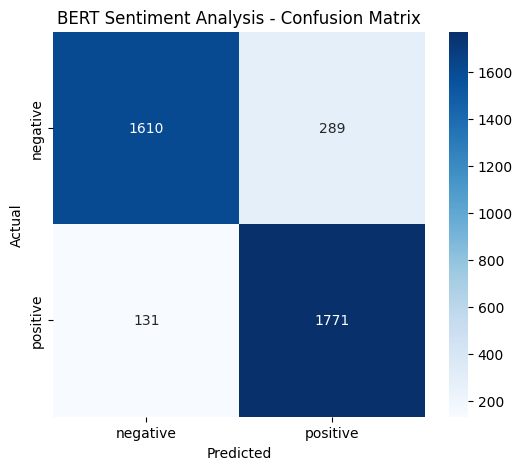

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BERT Sentiment Analysis - Confusion Matrix')
plt.show()

# Prediction probabilities

In [ ]:
torch.argmax(outputs.logits, dim=1)

tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
        0], device='cuda:0')

# model of confidence/probability

# Testing the Fine-tuned BERT Model Finally,

 evaluate the model on the test dataset. The test data has not been used to update the model parameters.

In [ ]:
import torch

model.eval()

count = 0

with torch.no_grad():
    for batch in test_dataloader:

        batch = {key: value.to(device) for key, value in batch.items()}

        outputs = model(**batch)

        # Probability
        probabilities = torch.softmax(outputs.logits, dim=1)

        # Highest probability + predicted class
        confidence, predictions = torch.max(probabilities, dim=1)

        # Print predictions
        for i in range(len(predictions)):

            sentiment = "Positive" if predictions[i].item() == 1 else "Negative"

            print(
                f"Prediction: {sentiment} | "
                f"Confidence: {confidence[i].item() * 100:.2f}%"
            )

            count +=1
            if count == 20:
                break
        break

Prediction: Positive | Confidence: 99.71%
Prediction: Negative | Confidence: 86.25%
Prediction: Positive | Confidence: 67.77%
Prediction: Negative | Confidence: 98.94%
Prediction: Negative | Confidence: 97.66%
Prediction: Negative | Confidence: 88.91%
Prediction: Negative | Confidence: 95.13%
Prediction: Positive | Confidence: 99.80%
Prediction: Positive | Confidence: 78.41%
Prediction: Negative | Confidence: 99.59%
Prediction: Negative | Confidence: 98.98%
Prediction: Positive | Confidence: 73.25%
Prediction: Negative | Confidence: 97.32%
Prediction: Positive | Confidence: 99.15%
Prediction: Positive | Confidence: 99.70%
Prediction: Positive | Confidence: 99.67%
Prediction: Negative | Confidence: 99.00%
Prediction: Negative | Confidence: 99.58%
Prediction: Positive | Confidence: 98.89%
Prediction: Positive | Confidence: 67.39%


In [ ]:
model.eval()

test_preds = []
test_labels_list = []

with torch.no_grad():

    for batch in test_dataloader:

        labels = batch['labels']

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = model(**batch)

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        test_preds.extend(
            predictions.cpu().numpy()
        )

        test_labels_list.extend(
            batch["labels"].cpu().labels.numpy()
        )

In [ ]:
print("Test Accuracy:",
      accuracy_score(test_labels_list, test_preds))

print("\nClassification Report:")
print(classification_report(
    test_labels_list,
    test_preds,
    target_names=["Negative", "Positive"],
    digits=4
))

Test Accuracy: 0.8847671665351223

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9221    0.8405    0.8794      1900
    Positive     0.8536    0.9290    0.8897      1901

    accuracy                         0.8848      3801
   macro avg     0.8878    0.8848    0.8845      3801
weighted avg     0.8878    0.8848    0.8845      3801



# Confusion Matrix

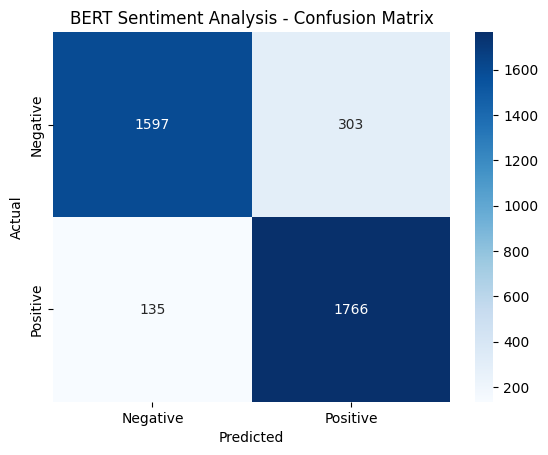

In [ ]:
cm = confusion_matrix(
    test_labels_list,
    test_preds
)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BERT Sentiment Analysis - Confusion Matrix')
plt.show()

In [ ]:
def predict_sentiment(review):
  model.eval()

  encoding = tokenizer(
      review,
      truncation=True,
      padding = "max_length",
      max_length=128,
      return_tensors="pt"
  )

  encoding = {key: value.to(device) for key, value in encoding.items()}

  with torch.no_grad():
    outputs = model(**encoding)
    probabilities = torch.softmax(outputs.logits, dim=1)
    confidence, predictions = torch.max(probabilities, dim=1)

  sentiment = "Positive" if predictions.item() == 1 else "Negative"

  return sentiment, confidence.item() * 100



In [ ]:
review = "This movie was absolutely amazing!"

sentiment, confidence = predict_sentiment(review)

print("Sentiment:", sentiment)
print(f"Confidence: {confidence:.2f}%")

Sentiment: Positive
Confidence: 99.36%


In [ ]:
save_path = "/content/drive/MyDrive/BERT_Sentiment_Model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/BERT_Sentiment_Model/tokenizer_config.json',
 '/content/drive/MyDrive/BERT_Sentiment_Model/tokenizer.json')

In [ ]:
from transformers import BertTokenizerFast, BertForSequenceClassification

tokenizer = BertTokenizerFast.from_pretrained(save_path)

model = BertForSequenceClassification.from_pretrained(save_path)

model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,